# Shallow Water via DLRA + DEIM (KSL integrator)

Vector-invariant shallow water equations on a doubly-periodic grid, integrated
in low-rank form with the interpolatory projector-splitting (KSL) integrator and
DEIM/ARP index selection.

In [1]:
# Loads the full DLRA + SWM stack through the single entry file.
include("./SWM/SWM.jl")

using Plots
using LinearAlgebra
using Random
using ProgressMeter
using .LowRank
using .InitialConditions
using .SWERhs
using .KSLMatrixSolver

## Grid and physical parameters

In [8]:
N     = 512
radz  = 6371.22e3
grav  = 9.80616
omega = 7.292e-5
pcori = 2 * omega          # constant Coriolis parameter f
H0    = 10e3
Lx    = 2π * radz
dx    = Lx / N
U0    = 20.0

# Gravity-wave CFL timestep. cfl=0.45 (the leapfrog reference value) is far too
# aggressive for this KSL+RK4 scheme — it diverges in tens of steps even with an
# exactly-preserved IC. cfl=0.1 lasts ~700 steps before a slow instability grows;
# cfl=0.05 is stable for 1000+ steps (mass drift ~1e-8 throughout).
cfl = 0.45
dt  = cfl * dx / sqrt(grav * H0)

params = SWEParams(dx=dx, grav=grav, fcor=pcori)
println("N=$N  dx=$(round(dx)) m  dt=$(round(dt)) s  (cfl=$cfl)")

N=512  dx=78187.0 m  dt=112.0 s  (cfl=0.45)


## Initial condition

Geostrophically-balanced zonal jet. Each field is exactly low-rank.

padded ranks: [10, 10, 10]


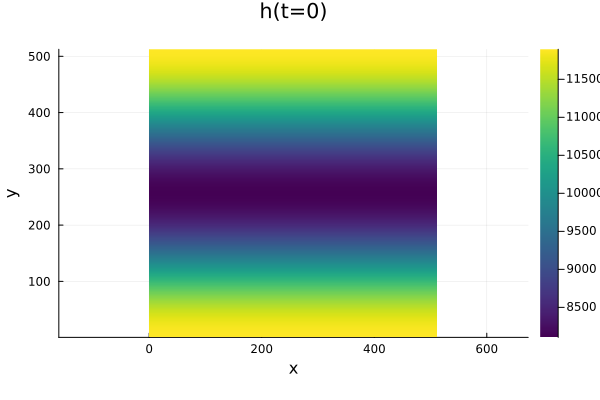

In [3]:
u, v, h = get_lr_geostrophic(N, dx; U0=U0, grav=grav, pcori=pcori, H0=H0)

# The geostrophic IC is exactly rank 1, so a fixed-rank-1 DLRA run can never
# develop 2D structure. Pad each field up to rank `r` WITHOUT perturbing it:
# append (r - rank) orthonormal basis columns to U and V with ZERO singular
# values. The dense field is unchanged; the integrator just gets empty modes
# to populate. (Adding random noise instead seeds a grid-scale instability.)
function zero_pad(Y::LRMat{T}, r::Int; rng=Random.default_rng()) where {T}
    n1, n2 = size(Y)
    r0 = LowRank.rank(Y)
    r <= r0 && return Y
    add = r - r0

    Uext = randn(rng, n1, add); Uext .-= Y.U * (Y.U' * Uext)
    Uext = Matrix(qr(Uext).Q)[:, 1:add]
    Vext = randn(rng, n2, add); Vext .-= Y.V * (Y.V' * Vext)
    Vext = Matrix(qr(Vext).Q)[:, 1:add]

    U = hcat(Y.U, Uext)
    V = hcat(Y.V, Vext)
    S = zeros(T, r, r); S[1:r0, 1:r0] .= Y.S
    return LRMat(U, S, V)
end

r   = 10
rng = MersenneTwister(1)
Ys  = [zero_pad(u, r; rng=rng), zero_pad(v, r; rng=rng), zero_pad(h, r; rng=rng)]

println("padded ranks: ", [LowRank.rank(Y) for Y in Ys])

heatmap(dense(Ys[3])', aspect_ratio=1, c=:viridis, title="h(t=0)",
        xlabel="x", ylabel="y")

## Time integration

One `ksl_step` advances the field vector `[u, v, h]` by `dt`. The RHS holds a
frozen snapshot of all three fields; oversampling `k = rank + Δ` stabilises the
DEIM projection.

In [4]:
nsteps    = 10000
plotevery = 100
oversamp  = 1          # DEIM oversampling beyond each field's rank (k = rank + Δ)

mass0  = sum(dense(Ys[3]))
frames = Any[]         # collected h snapshots for plotting

prog = Progress(nsteps; desc="integrating", showspeed=true)
for s in 1:nsteps
    G  = swe_rhs(Ys[1], Ys[2], Ys[3], params)
    kK = [min(N, LowRank.rank(Y) + oversamp) for Y in Ys]
    global Ys = ksl_step(Ys, G, (s-1)*dt, dt, LieTrotter(), RK4(), kK, kK)

    hf = dense(Ys[3])
    if !all(isfinite, hf)
        @warn "solution diverged at step $s — stopping (reduce cfl)"
        break
    end
    s % plotevery == 0 && push!(frames, (s, copy(hf)))

    next!(prog; showvalues=[(:step, s),
                            (:ranks, [LowRank.rank(Y) for Y in Ys]),
                            (:mass_drift, round(abs(sum(hf) - mass0) / abs(mass0), sigdigits=3))])
end

integrating   0%|                          |  ETA: 8:14:15 ( 2.97  s/it)


integrating   0%|                          |  ETA: 1:41:49 ( 0.61  s/it)


integrating   0%|                          |  ETA: 1:15:49 ( 0.46  s/it)


integrating   0%|                          |  ETA: 0:57:42 ( 0.35  s/it)


integrating   0%|▏                         |  ETA: 0:49:25 ( 0.30  s/it)


integrating   0%|▏                         |  ETA: 0:41:49 ( 0.25  s/it)


integrating   0%|▏                         |  ETA: 0:40:12 ( 0.24  s/it)


integrating   0%|▏                         |  ETA: 0:36:18 ( 0.22  s/it)


integrating   0%|▏                         |  ETA: 0:32:24 ( 0.20  s/it)


integrating   0%|▏                         |  ETA: 0:30:32 ( 0.18  s/it)


integrating   0%|▏                         |  ETA: 0:29:03 ( 0.18  s/it)


integrating   1%|▏                         |  ETA: 0:28:17 ( 0.17  s/it)


integrating   1%|▏                         |  ETA: 0:26:40 ( 0.16  s/it)


integrating   1%|▏       

ArgumentError: ArgumentError: arp_algorithm: input contains non-finite values (NaN/Inf). The upstream low-rank state has diverged.

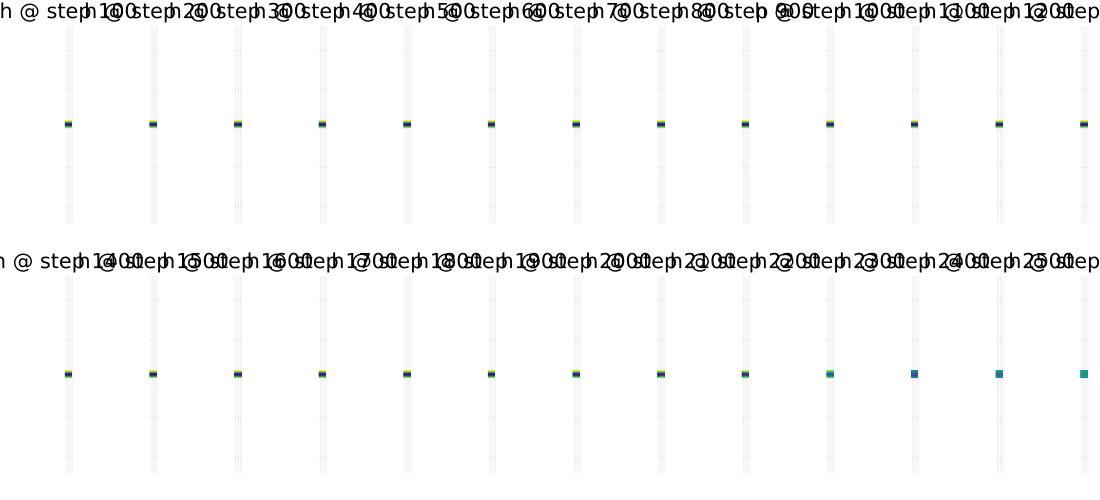

In [5]:
# h field at each recorded snapshot (every `plotevery` steps)
plts = [heatmap(hf', aspect_ratio=1, c=:viridis, title="h @ step $s",
                colorbar=false, axis=false)
        for (s, hf) in frames]
plot(plts..., layout=(2, ceil(Int, length(plts)/2)), size=(1100, 500))

## Cross-check: simple Euler + truncate solver

`euler_step` is a first-order reference integrator. It forms the oblique DEIM
projection of the RHS, `Ĝ = P_U·G + G·P_V − P_U·G·P_V`, takes a plain Euler
step, and truncates back to rank. No K/S/L splitting — useful to sanity-check
the fields the KSL integrator produces. (Less accurate / less stable than KSL.)

In [11]:
# Independent run with the Euler+truncate solver (own copy of the IC).
Ye = [zero_pad(u, r; rng=MersenneTwister(1)),
      zero_pad(v, r; rng=MersenneTwister(2)),
      zero_pad(h, r; rng=MersenneTwister(3))]

nsteps_e  = 1000
plotevery = 10
oversamp  = 4                       # DEIM oversampling
fixedrank = fill(r, 3)              # hold rank = r (drop `ranks=` to let it shrink)

mass0_e  = sum(dense(Ye[3]))
frames_e = Any[]

prog = Progress(nsteps_e; desc="euler", showspeed=true)
for s in 1:nsteps_e
    G  = swe_rhs(Ye[1], Ye[2], Ye[3], params)
    k  = [min(N, LowRank.rank(Y) + oversamp) for Y in Ye]
    global Ye = euler_step(Ye, G, (s-1)*dt, dt, k; ranks=fixedrank)

    hf = dense(Ye[3])
    if !all(isfinite, hf)
        @warn "euler diverged at step $s — stopping (reduce cfl)"
        break
    end
    s % plotevery == 0 && push!(frames_e, (s, copy(hf)))

    next!(prog; showvalues=[(:step, s),
                            (:ranks, [LowRank.rank(Y) for Y in Ye]),
                            (:mass_drift, round(abs(sum(hf) - mass0_e) / abs(mass0_e), sigdigits=3))])
end

euler   0%|▏                               |  ETA: 0:03:04 ( 0.18  s/it)


euler   0%|▏                               |  ETA: 0:04:14 ( 0.25  s/it)


euler   0%|▏                               |  ETA: 0:03:44 ( 0.23  s/it)


euler   0%|▏                               |  ETA: 0:03:28 ( 0.21  s/it)


euler   1%|▎                               |  ETA: 0:03:23 ( 0.20  s/it)


euler   1%|▎                               |  ETA: 0:03:45 ( 0.23  s/it)


euler   1%|▎                               |  ETA: 0:03:33 ( 0.22  s/it)


euler   1%|▎                               |  ETA: 0:03:25 ( 0.21  s/it)


euler   1%|▍                               |  ETA: 0:03:19 ( 0.20  s/it)


euler   1%|▍                               |  ETA: 0:03:37 ( 0.22  s/it)


euler   1%|▍                               |  ETA: 0:03:30 ( 0.21  s/it)


euler   1%|▍                               |  ETA: 0:03:24 ( 0.21  s/it)


euler   1%|▌                               |  ETA: 0:03:18 ( 0.20  s/it)


euler   2%|▌             

ArgumentError: ArgumentError: invalid argument #4 to LAPACK call

In [10]:
# Euler-solver h snapshots
plts_e = [heatmap(hf', aspect_ratio=1, c=:viridis, title="h(euler) @ step $s",
                  colorbar=false, axis=false)
          for (s, hf) in frames_e]
plot(plts_e..., layout=(2, ceil(Int, length(plts_e)/2)), size=(1100, 500))